In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm                                 # built in color maps
from sklearn.model_selection import train_test_split
import random

def points_within_circle(radius, center=(0, 0), number_of_points=100):
    center_x, center_y = center
    r = radius * np.sqrt(np.random.random((number_of_points,)))
    theta = np.random.random((number_of_points,)) * 2 * np.pi
    # print('r', r)
    # print('theta', theta)
    x = center_x + r * np.cos(theta)  # use cosine to find x values
    y = center_y + r * np.sin(theta)  # use sine to find y values
    # print('x', x)
    # print('y', y)
    return x, y

oranges_x, oranges_y = points_within_circle(1.6, (5, 2), 100)
lemons_x, lemons_y = points_within_circle(1.9, (2, 5), 100)

oranges = list(zip(oranges_x, oranges_y))
lemons = list(zip(lemons_x, lemons_y))

# labelling oranges with 0 and lemons with 1:
labelled_data = list(zip(oranges + lemons, [0] * len(oranges) + [1] * len(lemons)))
random.shuffle(labelled_data)

data, labels = zip(*labelled_data)

res = train_test_split(data, labels, train_size=0.8, test_size=0.2, random_state=42)
train_data, test_data, train_labels, test_labels = res

class Perceptron:
    def __init__(self, weights, learning_rate=0.1):
        """
        'weights' can be a numpy array, list or a tuple with the actual values of the weights. The number of input
        values is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.learning_rate = learning_rate
        # print('weights , learning_rate', weights, learning_rate)

    @staticmethod
    def unit_step_function(x):
        if x < 0:
            return 0
        else:
            return 1

    def __call__(self, in_data):
        weighted_input = self.weights * in_data
        weighted_sum = weighted_input.sum()
        # print('in_data, weighted_input, weighted_sum', in_data, weighted_input, weighted_sum)
        return Perceptron.unit_step_function(weighted_sum)

    def adjust(self, target_result, calculated_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)      #
        error = target_result - calculated_result
        if error != 0:
            correction = error * in_data * self.learning_rate
            self.weights += correction
            # print(target_result, calculated_result, error, in_data, correction, self.weights)

    """
    A static method can be called either on the class (such as P.evaluate()) or on an instance (such as P().evaluate()). 
    Moreover, they can be called as regular functions (such as evaluate()).
    """
    @staticmethod
    def evaluate(data, labels):
        evaluation = Counter()
        for index in range(len(data)):
            # print('Evaluation index = ', index)
            label = int(round(p(data[index]), 0))
            if label == labels[index]:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation


--------------
To match the colors exactly to the number of updates, you have two main options. The first is to "pre-calculate" the number of mistakes, and the second is to use a continuous colormap that samples a new color every time the weights shift.

Here is how you can implement both.

Option 1: The "Pre-calculate" Method
Since the Perceptron only updates when it makes a mistake, we can run a quick check to see how many updates will occur. This allows us to create a color palette where the first update is one color (e.g., Red) and the very last update is another (e.g., Violet), with a smooth transition in between.

----------

In [2]:
# 1. Count how many updates will happen
total_updates = 0
temp_p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)
for i in range(len(train_data)):
    pred = temp_p(train_data[i])
    if pred != train_labels[i]:
        total_updates += 1
        temp_p.adjust(train_labels[i], pred, train_data[i])

# 2. Create exactly that many colors
colors = cm.rainbow(np.linspace(0, 1, total_updates))
colors

array([[5.00000000e-01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [2.49019608e-01, 3.84105749e-01, 9.80634770e-01, 1.00000000e+00],
       [1.96078431e-03, 7.09281308e-01, 9.23289106e-01, 1.00000000e+00],
       [2.52941176e-01, 9.25637660e-01, 8.30184031e-01, 1.00000000e+00],
       [5.03921569e-01, 9.99981027e-01, 7.04925547e-01, 1.00000000e+00],
       [7.54901961e-01, 9.20905518e-01, 5.52364973e-01, 1.00000000e+00],
       [1.00000000e+00, 7.00543038e-01, 3.78411050e-01, 1.00000000e+00],
       [1.00000000e+00, 3.72701992e-01, 1.89801093e-01, 1.00000000e+00],
       [1.00000000e+00, 1.22464680e-16, 6.12323400e-17, 1.00000000e+00]])

p.weights : [0.1 0.1]        old_weights : [0.1 0.1]
p.weights : [-1.5210156  -0.44482788]        old_weights : [0.1 0.1]
1 0 -3.4193351060047332 [-1.5210156  -0.44482788] (np.float64(5.403385317755601), np.float64(1.8160929422171455))
counter : 1
p.weights : [-1.33496302  0.72533935]        old_weights : [-1.5210156  -0.44482788]
2 1 1.8404668287787997 [-1.33496302  0.72533935] (np.float64(0.6201752578286177), np.float64(3.9005574507206378))
counter : 2
p.weights : [-1.33496302  0.72533935]        old_weights : [-1.33496302  0.72533935]
p.weights : [-1.33496302  0.72533935]        old_weights : [-1.33496302  0.72533935]
p.weights : [-0.5522172   1.85285939]        old_weights : [-1.33496302  0.72533935]
5 2 0.29803513800826936 [-0.5522172   1.85285939] (np.float64(2.609152715044805), np.float64(3.758400118746503))
counter : 3
p.weights : [-2.20926491  0.97815802]        old_weights : [-0.5522172   1.85285939]
6 3 2.2585971517444974 [-2.20926491  0.97815802] (np.float64(5.5234923575344

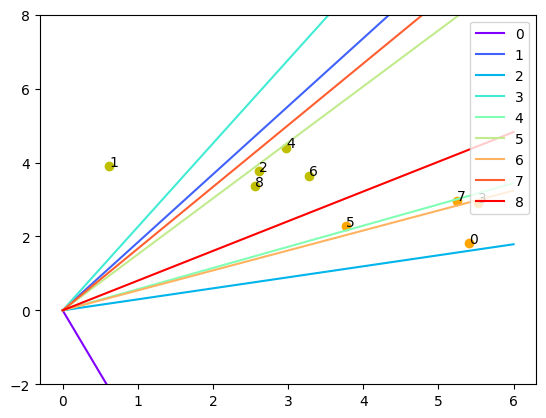

In [3]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])

counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()               # copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    print(f'p.weights : {p.weights}        old_weights : {old_weights}')
    
    if not np.array_equal(old_weights, p.weights):
        color = "orange" if train_labels[index] == 0 else "y"

        ax.scatter(train_data[index][0], train_data[index][1], color=color)
        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))

        m = -p.weights[0] / p.weights[1]
        print(index, counter, m, p.weights, train_data[index])
        ax.plot(X, m * X, label=str(counter), color=colors[counter % len(colors)])
        counter += 1
        print(f'counter : {counter}')
        """
        if counter >= 7:
            counter = 0
        """
ax.legend(loc='upper right')
plt.show()

----
The "Stretched" Gradient (Best for many updates)
If you want to keep the rainbow look, use rainbow and multiply the counter to "jump" further ahead in the spectrum.

Inside your IF statement, change how you pick the color:
This jumps 10% through the rainbow for every mistake
current_color = cm.rainbow((counter * 0.1) % 1.0)

-----

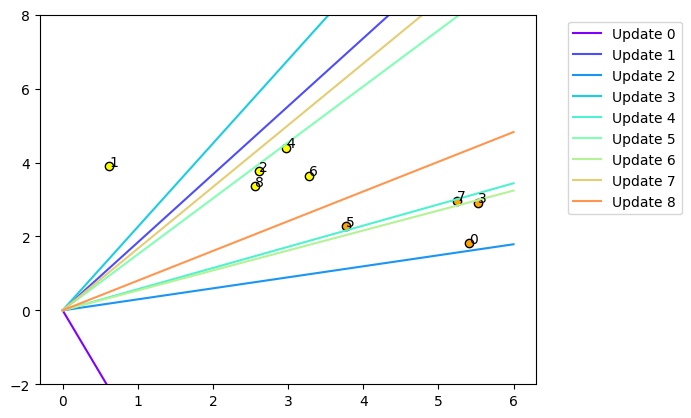

In [4]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])


counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    # print(f'p.weights : {p.weights}        old_weights : {old_weights}')
    
    if not np.array_equal(old_weights, p.weights):
        # color_idx = counter % len(colors) # Double safety!
        # current_color = colors[color_idx]
        current_color = cm.rainbow((counter * 0.1) % 1.0)

        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))
        

        m = -p.weights[0] / p.weights[1]
        # Plotting logic
        ax.plot(X, m * X, label=f"Update {counter}", color=current_color)
        # ax.plot(X, m * X, label=f"Update {counter}", color=colors[index])
                  
        # Annotation and Scatter
        point_color = "orange" if train_labels[index] == 0 else "yellow"
        ax.scatter(train_data[index][0], train_data[index][1], color=point_color, edgecolors='k')
        
        counter += 1
        # print(f'counter : {counter}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if it's too big
plt.show()

"""
Each of the points in the diagram above cause a change in the weights. We see them numbered in the order of
their appearance and the corresponding straight line. This way we can see how the networks "learns".
"""

----------
Option 2: The Continuous Colormap (More Dynamic)
If you don't want to run the loop twice, you can use a colormap to pick a color based on the current index relative to the total_length of your data. This doesn't guarantee a perfectly even spread if updates are clustered, but it’s very efficient.

Revised Visualization Code
Here is the updated loop using a dynamic color selection. I've used a larger number_of_colors buffer so you don't have to worry about the IndexError even if the Perceptron struggles to converge.

-------

In [5]:
# Create a larger buffer of colors to be safe
number_of_colors = len(train_data) 
colors = cm.viridis(np.linspace(0, 1, number_of_colors))
# print(f'colrs : {colors}')

In [6]:
colors.shape,     colors.size

((160, 4), 640)

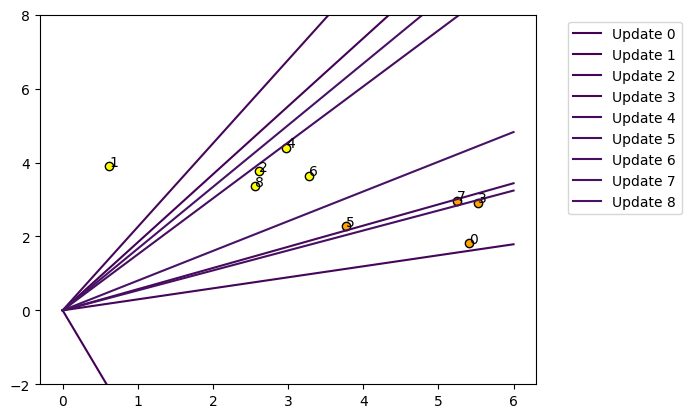

In [7]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])


counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    #print(f'p.weights : {p.weights}        old_weights : {old_weights}')
    
    if not np.array_equal(old_weights, p.weights):
        color_idx = counter % len(colors) # Double safety!
        current_color = colors[color_idx]

        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))
        

        m = -p.weights[0] / p.weights[1]
        # Plotting logic
        ax.plot(X, m * X, label=f"Update {counter}", color=current_color)
        # ax.plot(X, m * X, label=f"Update {counter}", color=colors[index])
                  
        # Annotation and Scatter
        point_color = "orange" if train_labels[index] == 0 else "yellow"
        ax.scatter(train_data[index][0], train_data[index][1], color=point_color, edgecolors='k')
        
        counter += 1
        #print(f'counter : {counter}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if it's too big
plt.show()

---------
Why this is better
Visual Progression: By using np.linspace(0, 1, num), the lines will transition through the spectrum (e.g., from purple to yellow). This makes it easy to see the "history" of how the decision boundary moved.

Legend Management: If you have many updates, the legend can get messy. I added bbox_to_anchor to move it to the side so it doesn't cover your plot.

------

In [8]:
# Get 10 colors evenly spaced from a continuous map
import matplotlib

viridis = matplotlib.colormaps['viridis']
cls = [viridis(i) for i in np.linspace(0, 1, 20)]

for c in cls:
    print(f'c : {c}')

c : (np.float64(0.267004), np.float64(0.004874), np.float64(0.329415), np.float64(1.0))
c : (np.float64(0.280894), np.float64(0.078907), np.float64(0.402329), np.float64(1.0))
c : (np.float64(0.28229), np.float64(0.145912), np.float64(0.46151), np.float64(1.0))
c : (np.float64(0.270595), np.float64(0.214069), np.float64(0.507052), np.float64(1.0))
c : (np.float64(0.250425), np.float64(0.27429), np.float64(0.533103), np.float64(1.0))
c : (np.float64(0.223925), np.float64(0.334994), np.float64(0.548053), np.float64(1.0))
c : (np.float64(0.19943), np.float64(0.387607), np.float64(0.554642), np.float64(1.0))
c : (np.float64(0.175841), np.float64(0.44129), np.float64(0.557685), np.float64(1.0))
c : (np.float64(0.15627), np.float64(0.489624), np.float64(0.557936), np.float64(1.0))
c : (np.float64(0.136408), np.float64(0.541173), np.float64(0.554483), np.float64(1.0))
c : (np.float64(0.121831), np.float64(0.589055), np.float64(0.545623), np.float64(1.0))
c : (np.float64(0.12478), np.float64(0

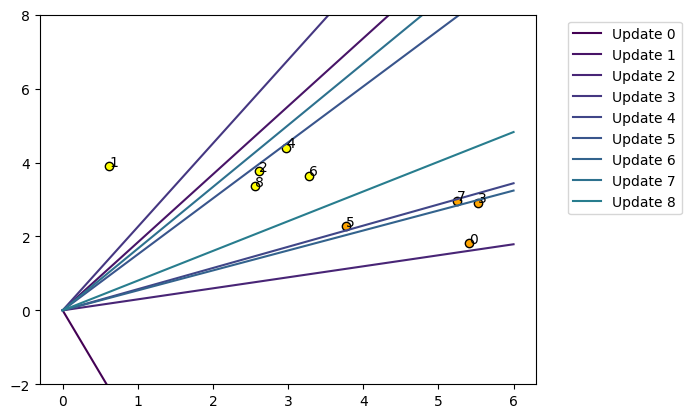

In [9]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])


counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    #print(f'p.weights : {p.weights}        old_weights : {old_weights}')
    
    if not np.array_equal(old_weights, p.weights):
        color_idx = counter % len(cls) # Double safety!
        current_color = cls[color_idx]

        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))
        

        m = -p.weights[0] / p.weights[1]
        # Plotting logic
        ax.plot(X, m * X, label=f"Update {counter}", color=current_color)
        # ax.plot(X, m * X, label=f"Update {counter}", color=colors[index])
                  
        # Annotation and Scatter
        point_color = "orange" if train_labels[index] == 0 else "yellow"
        ax.scatter(train_data[index][0], train_data[index][1], color=point_color, edgecolors='k')
        
        counter += 1
        #print(f'counter : {counter}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if it's too big
plt.show()

-----
If your train_data has 100 points, but your Perceptron only makes 5 or 10 mistakes, your code picks colors[0], colors[1], colors[2], etc. In a 100-color gradient, those first few shades are virtually identical dark purples.

The Contrast Fix
To make the color changes obvious, you should use a colormap with more distinct jumps or "stretch" your color selection.

Change your color initialization to one of these two options:

Option A: The Categorical Approach (Best for < 10 updates)
Use tab10 or tab20. These are designed to be distinctly different colors (Red, Blue, Green, etc.) rather than a smooth gradient.

----

In [10]:
# Replace your current color lines with this:
import matplotlib

#colors = cm.get_cmap('tab10').colors  # Provides 10 very distinct colors   # depricated

colors = matplotlib.colormaps['tab10']
# colors = matplotlib.colormaps.get_cmap('tab10')
# colors = matplotlib.colormaps.get_cmap('tab10')
print(f'colors : {colors}')

#cls = [ map for map in colors ]        # wrong
#print(f'cls : {cls}')
    

colors : <matplotlib.colors.ListedColormap object at 0x000001F84C5159D0>


--------
Matplotlib Colormap object is designed to be a callable function (mapping a value like 0.5 to a color) rather 
than a simple list of colors. Even though it contains colors, it isn't "iterable" by default.

Since tab10 is a ListedColormap, you can access its underlying array of colors using the .colors attribute.

-------

In [11]:
# 1. Get the colormap
colors = matplotlib.colormaps['tab10']

# 2. Access the .colors attribute (returns an N x 3 or N x 4 array)
cls = [ c for c in colors.colors ]

print(f'colors : {colors}')
print(f'cls (first 2) : {cls[:2]}')
print(f'Number of colors: {len(cls)}')

colors : <matplotlib.colors.ListedColormap object at 0x000001F84C515910>
cls (first 2) : [(0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (1.0, 0.4980392156862745, 0.054901960784313725)]
Number of colors: 10


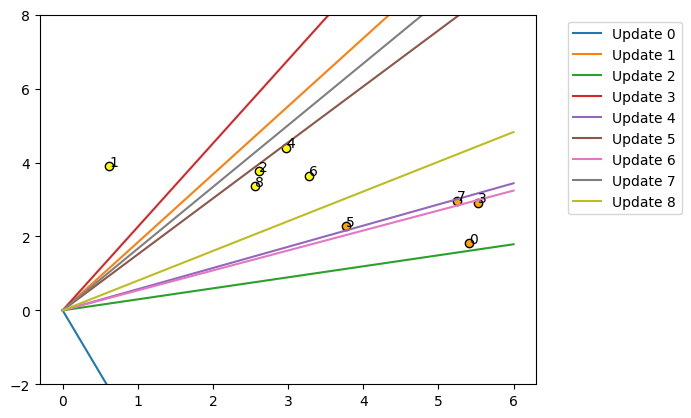

In [12]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])


counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    #print(f'p.weights : {p.weights}        old_weights : {old_weights}')
    
    if not np.array_equal(old_weights, p.weights):
        color_idx = counter % len(cls) # Double safety!
        current_color = cls[color_idx]

        ax.annotate(str(counter), (train_data[index][0], train_data[index][1]))
        

        m = -p.weights[0] / p.weights[1]
        # Plotting logic
        ax.plot(X, m * X, label=f"Update {counter}", color=current_color)
        # ax.plot(X, m * X, label=f"Update {counter}", color=colors[index])
                  
        # Annotation and Scatter
        point_color = "orange" if train_labels[index] == 0 else "yellow"
        ax.scatter(train_data[index][0], train_data[index][1], color=point_color, edgecolors='k')
        
        counter += 1
        #print(f'counter : {counter}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if it's too big
plt.show()

Update 1: Weights updated to [-1.5210156  -0.44482788]
Update 2: Weights updated to [-1.33496302  0.72533935]
Update 3: Weights updated to [-0.5522172   1.85285939]
Update 4: Weights updated to [-2.20926491  0.97815802]
Update 5: Weights updated to [-1.31792273  2.29941035]
Update 6: Weights updated to [-2.44735188  1.61570318]
Update 7: Weights updated to [-1.46391125  2.71002173]
Update 8: Weights updated to [-3.03732848  1.81902418]
Update 9: Weights updated to [-2.27134649  2.82452863]


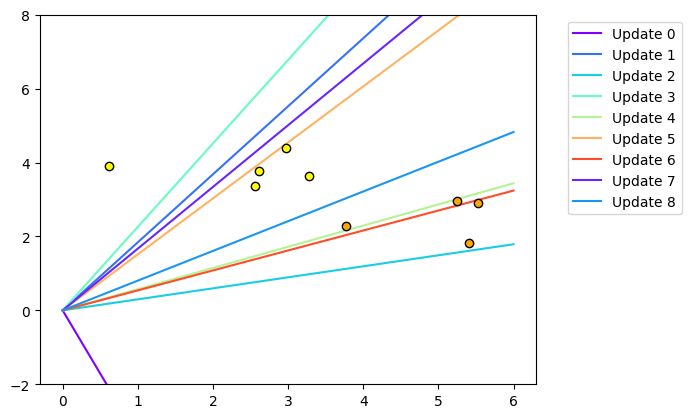

In [13]:
p = Perceptron(weights=[0.1, 0.1], learning_rate=0.3)

X = np.arange(0, 7)

fig, ax = plt.subplots()

ax.set_xticks(range(8))
ax.set_ylim([-2, 8])


counter = 0
for index in range(len(train_data)):
    old_weights = p.weights.copy()
    p.adjust(train_labels[index], p(train_data[index]), train_data[index])
    
    if not np.array_equal(old_weights, p.weights):
        # Use a distinct jump in the rainbow spectrum (e.g., 0.1 per update)
        current_color = cm.rainbow((counter * 0.15) % 1.0) 

        # Calculate slope safely
        m = -p.weights[0] / (p.weights[1] + 1e-9)
        
        # Plot the update
        ax.plot(X, m * X, label=f"Update {counter}", color=current_color, linewidth=1.5)
        
        # Mark the point that caused the mistake
        point_color = "orange" if train_labels[index] == 0 else "yellow"
        ax.scatter(train_data[index][0], train_data[index][1], 
                   color=point_color, edgecolors='k', zorder=5)
        
        counter += 1
        print(f'Update {counter}: Weights updated to {p.weights}')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside if it's too big
plt.show()